In [35]:
## Ignore this code, this is just generating some data
library(infer)
library(tidyverse)

options(ark.plot.width = 10)
options(ark.plot.height = 5)

## 1. **AN**alysis **O**f **VA**riance (ANOVA)

- We learned how to compare the mean of two groups: `t.test` or permutation test.

- But how does it work when we have more than two groups?

- For example, imagine we have $k$ groups. We set the hypotheses to be:
$$H_0: \mu_1=\mu_2=...=\mu_k\quad\quad vs \quad\quad H_A: \mu_i\neq \mu_j, \text{ for at least one } i\neq j$$
    
- In other words, the alternative hypothesis of ANOVA suggests that at least one group has a different mean
    - We don't need all the groups to have a different mean. It is enough that one group has a different mean for $H_0$ to be false.      
    
- Let's explore ANOVA with an example.

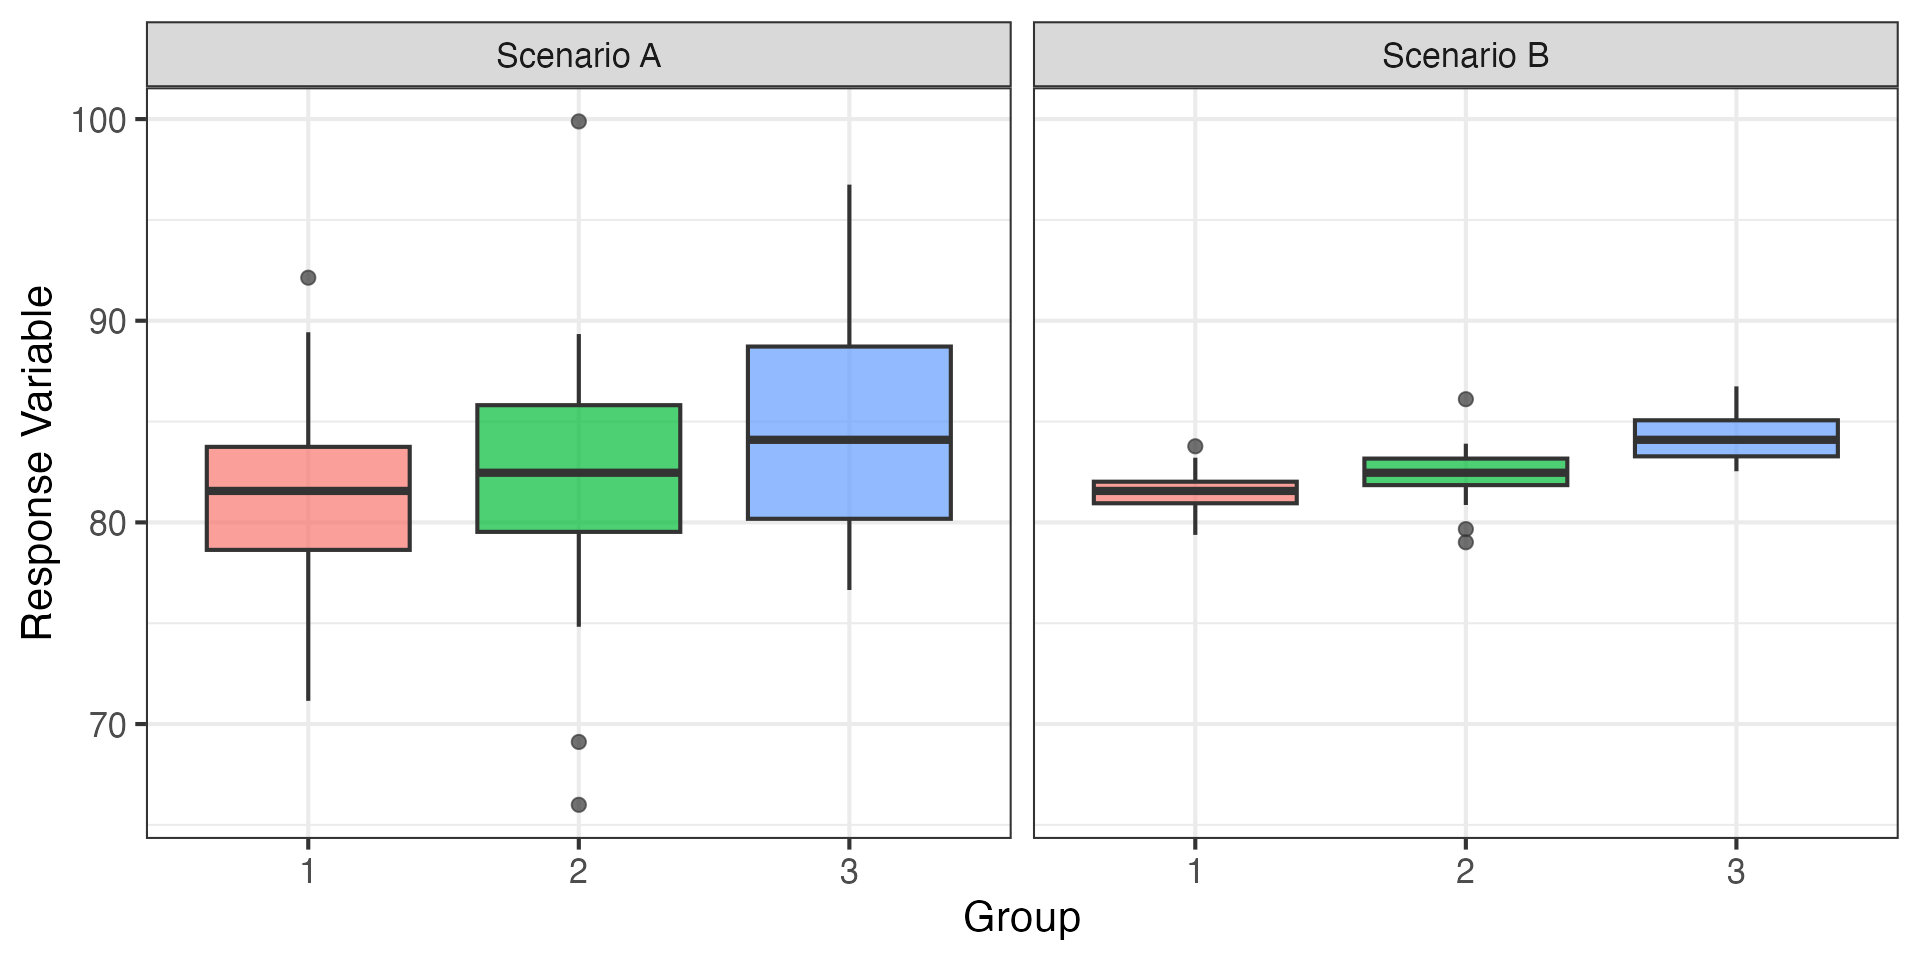

In [36]:
# cell-01
# Visualizing within-group vs. between-group variation
set.seed(654321)
n_sample <- 30
mus <- c(80, 82, 87)

# Left plot: Normal Variance (high overlap between boxplots)
data_left <- tibble(
  group = factor(rep(1:3, each = n_sample)),
  mu = rep(mus, each = n_sample)
) %>%
  mutate(val = rnorm(n(), mean = mu, sd = 5.5))

# Right plot: Small Variance (same group means X-bar, scaled variance -> no overlap)
new_std <- 1.2
data_right <- data_left %>%
  group_by(group) %>%
  mutate(val = new_std * (val - median(val)) / sd(data_left$val) + median(val)) %>%
  ungroup()

data_left <- data_left %>% mutate(scenario = "Scenario A")
data_right <- data_right %>% mutate(scenario = "Scenario B")

data_comp <- bind_rows(data_left, data_right) %>%
  mutate(scenario = factor(scenario, levels = c("Scenario A", "Scenario B")))

ggplot(data_comp, aes(x = group, y = val, fill = group)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~ scenario) +
  labs(x = "Group", y = "Response Variable", fill = "Group") +
  theme_bw(base_size = 16) +
  theme(legend.position = "none")

### 1.1 cars dataset

In [37]:
# cell-02
mtcars

                     mpg cyl  disp  hp drat    wt  qsec vs am gear carb
Mazda RX4           21.0   6 160.0 110 3.90 2.620 16.46  0  1    4    4
Mazda RX4 Wag       21.0   6 160.0 110 3.90 2.875 17.02  0  1    4    4
Datsun 710          22.8   4 108.0  93 3.85 2.320 18.61  1  1    4    1
Hornet 4 Drive      21.4   6 258.0 110 3.08 3.215 19.44  1  0    3    1
Hornet Sportabout   18.7   8 360.0 175 3.15 3.440 17.02  0  0    3    2
Valiant             18.1   6 225.0 105 2.76 3.460 20.22  1  0    3    1
Duster 360          14.3   8 360.0 245 3.21 3.570 15.84  0  0    3    4
Merc 240D           24.4   4 146.7  62 3.69 3.190 20.00  1  0    4    2
Merc 230            22.8   4 140.8  95 3.92 3.150 22.90  1  0    4    2
Merc 280            19.2   6 167.6 123 3.92 3.440 18.30  1  0    4    4
Merc 280C           17.8   6 167.6 123 3.92 3.440 18.90  1  0    4    4
Merc 450SE          16.4   8 275.8 180 3.07 4.070 17.40  0  0    3    3
Merc 450SL          17.3   8 275.8 180 3.07 3.730 17.60  0  0   

In [38]:
# cell-03
# Let's make cyl a factor
cars <- mtcars %>%
    mutate(cyl = as_factor(cyl))

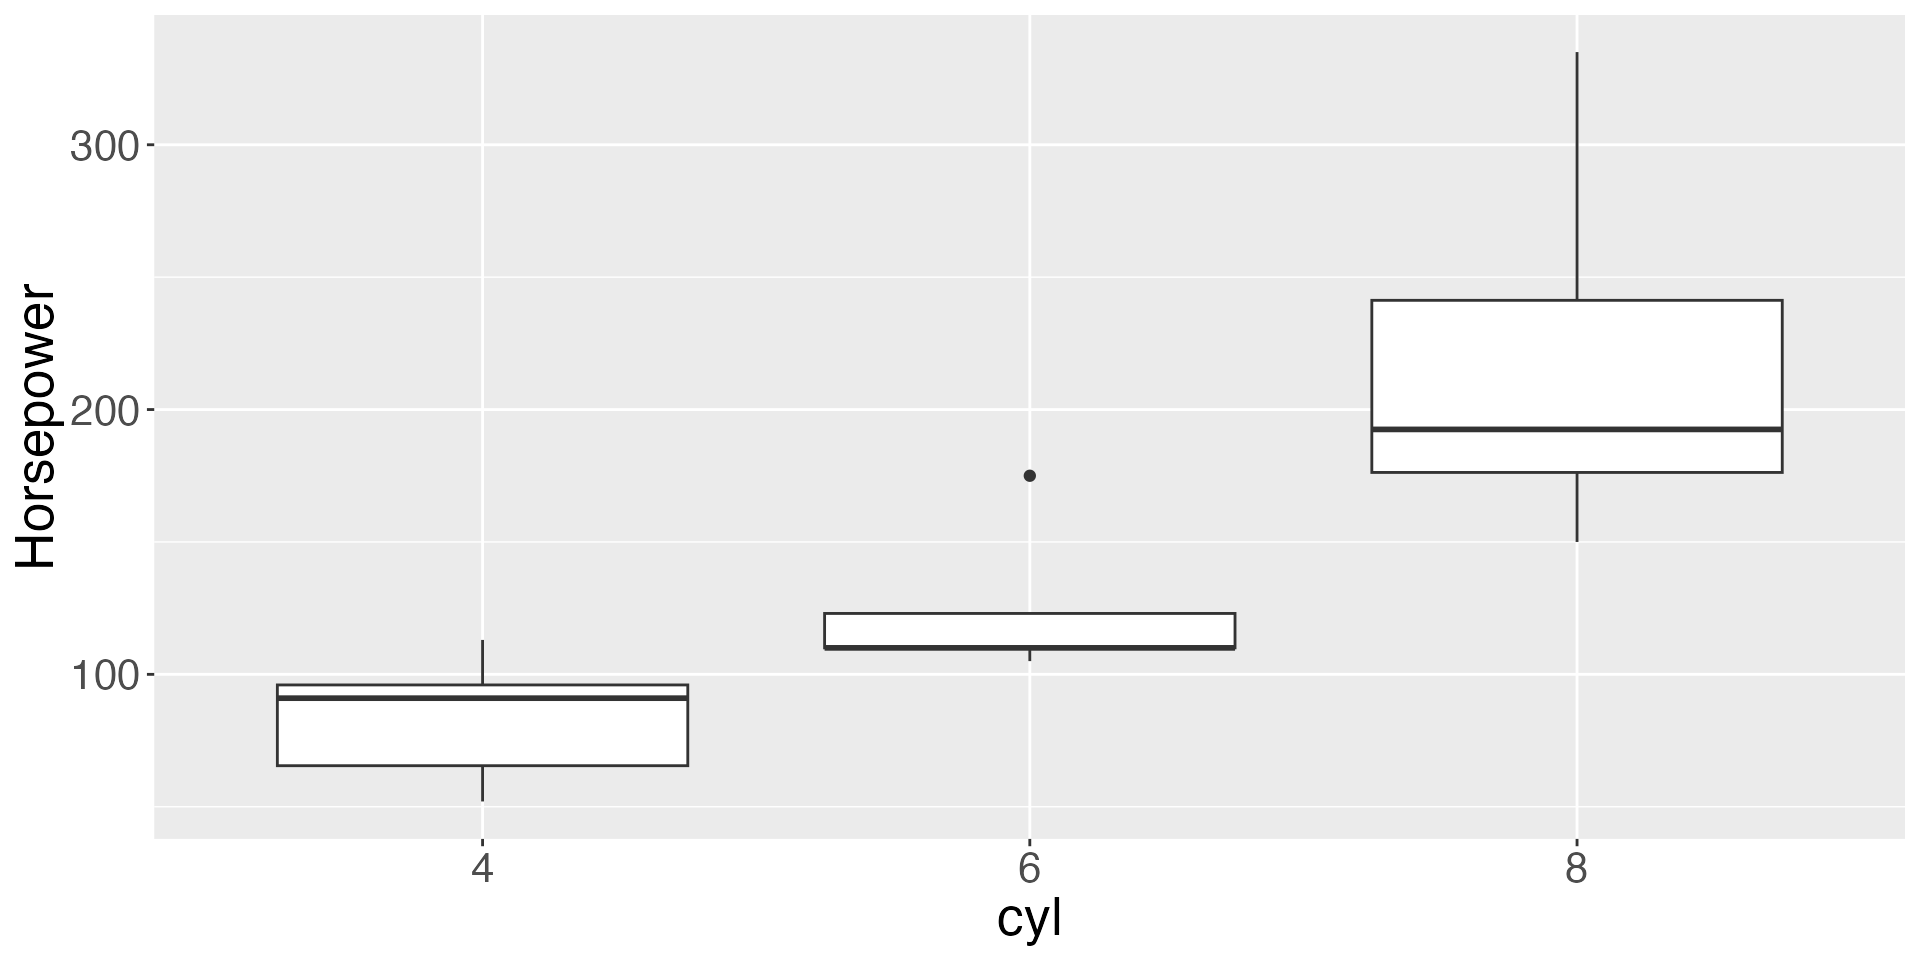

In [39]:
# cell-04
# Let's take a look
cars %>%
    ggplot(aes(cyl, hp)) + 
    geom_boxplot() + 
    ylab('Horsepower') + 
    theme(text = element_text(size = 20))

- The idea of ANOVA is to compare the variation within each group/category against the variation between the groups/category.

- If the within-group spread is small compared to the between-group spread, then we have evidence of difference.

### 1.2 Variability within the groups (SSE)

- We want to see how spread the points of a group are around its mean.

1. We take the difference of each point to the mean of its group.
2. Take the square of these differences;
3. Sum the square difference for all points

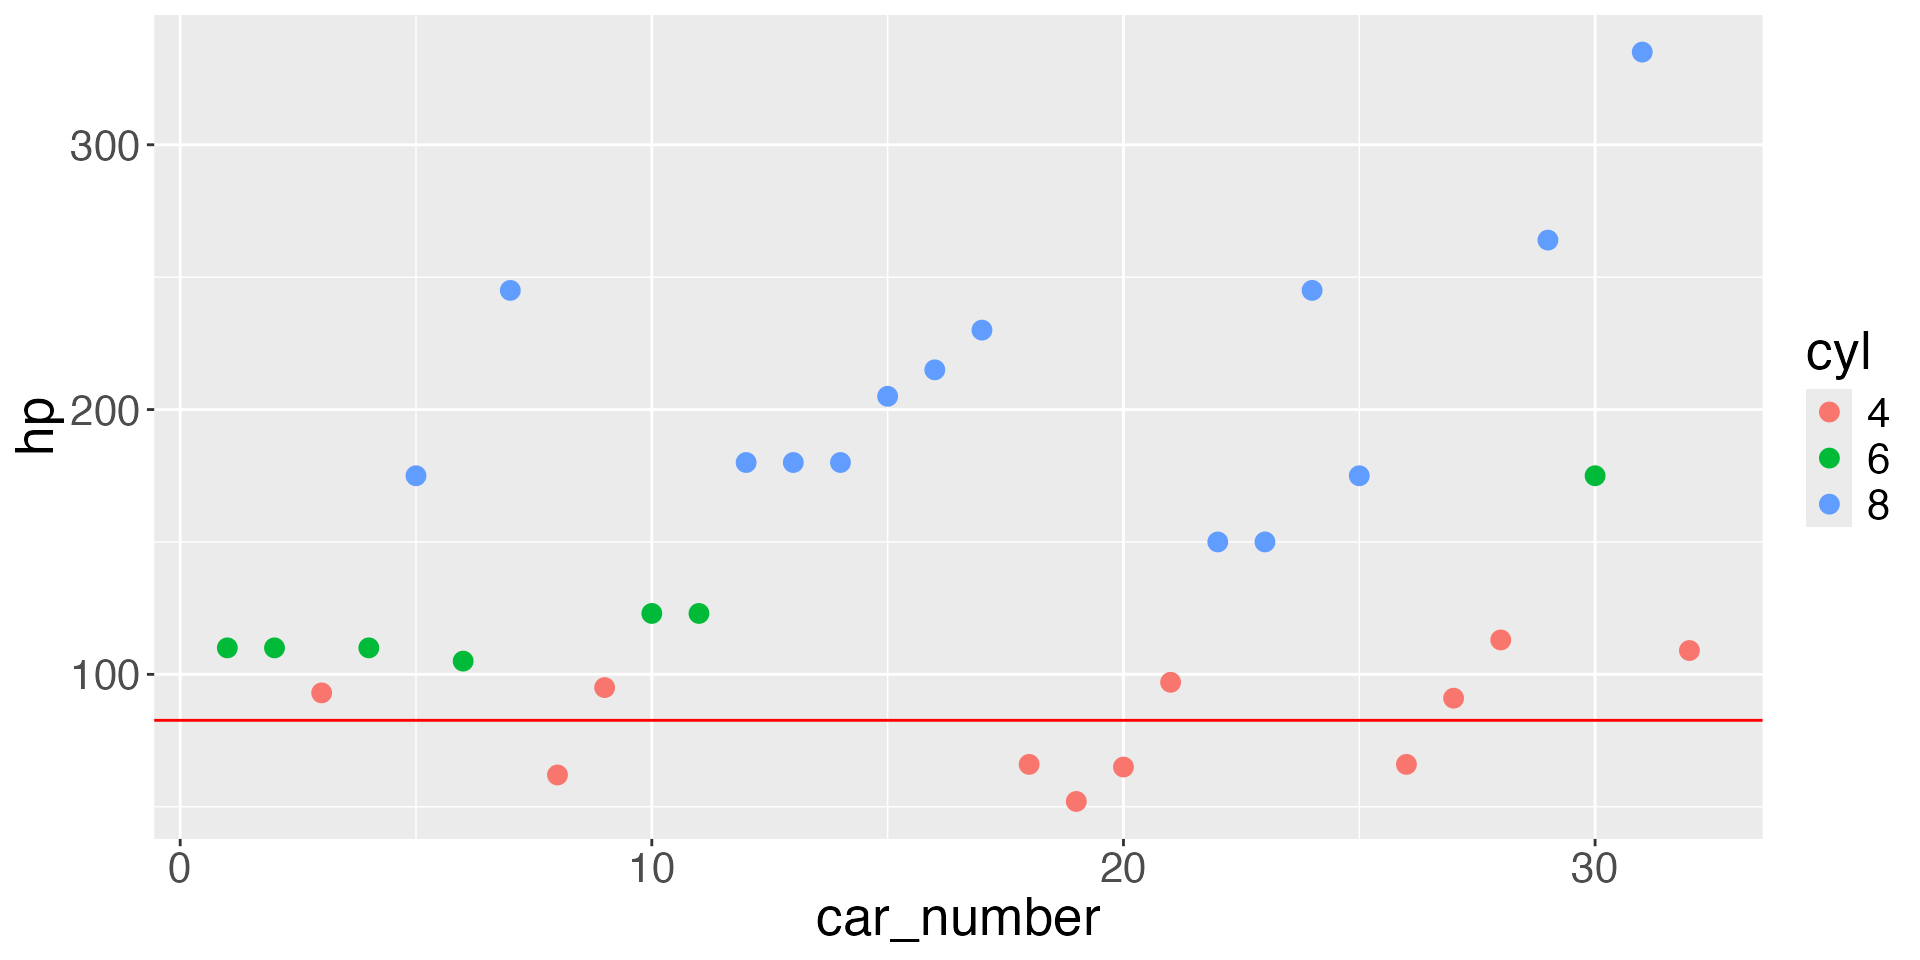

In [ ]:
# cell-05
# Let's plot the data
cars |>
    mutate(car_number = 1:nrow(cars)) |>
    ggplot(aes(car_number, hp, color = cyl)) + 
    geom_point(size=3) +
    theme(text = element_text(size = 20)) #+ 
    #geom_hline(aes(yintercept = cars %>% filter(cyl == 4) %>% pull(hp) %>% mean()), color = 'red') +
    #geom_hline(aes(yintercept = cars %>% filter(cyl == 6) %>% pull(hp) %>% mean()), color = 'darkgreen') +
    #geom_hline(aes(yintercept = cars %>% filter(cyl == 8) %>% pull(hp) %>% mean()), color = 'blue')

In [41]:
# cell-06
# Calculate the SSE
SSE <-
    cars %>% 
    group_by(cyl) %>%
    mutate(group_avg = mean(hp)) %>%
    ungroup() %>%
    summarise(SSE = sum((hp - group_avg)**2)) %>%
    pull(SSE)

SSE

[1] 41696.33

### 1.3 Variability between groups (SST)

- We want to see how the **mean** of each group varies around the **overall mean** (the mean considering all the points of all the groups).
  
1. Take the difference between the mean of each group and the overall mean;
2. Take the square of the difference
3. Multiply the square difference by the number of points in the group.

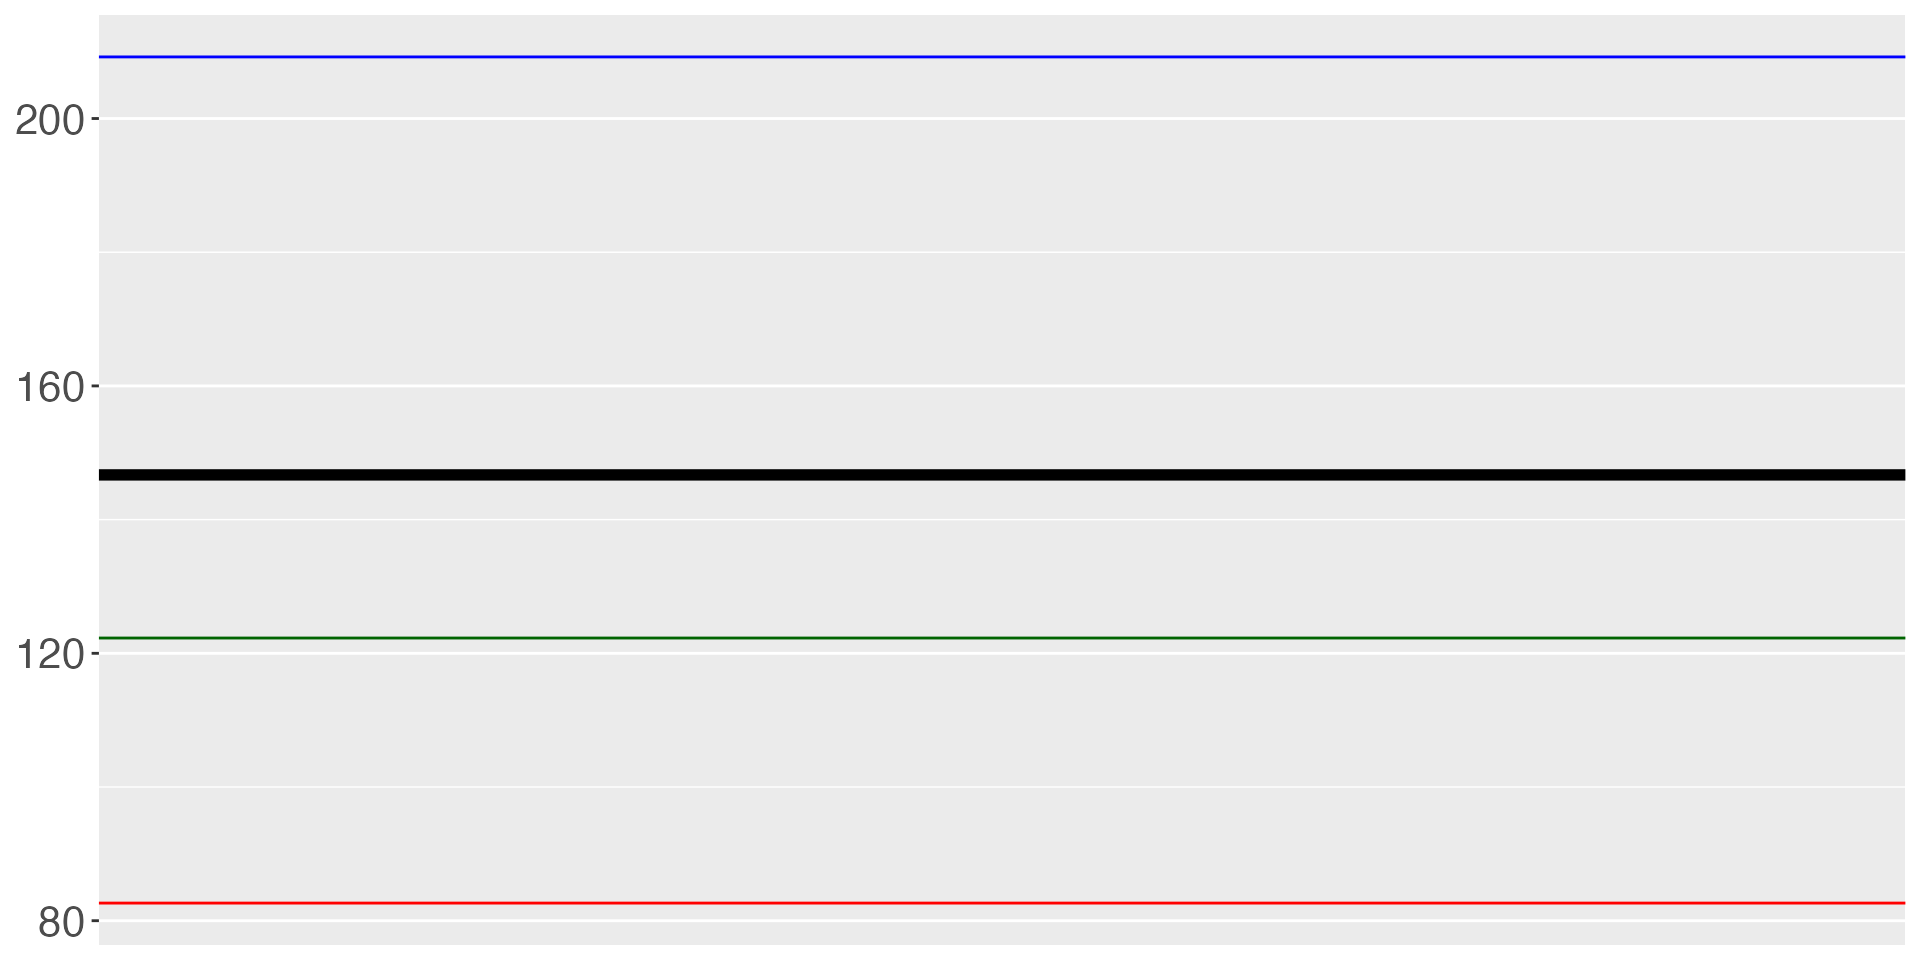

In [42]:
# cell-07
# Plot the means for the variability between groups
cars %>%
    mutate(car_number = 1:nrow(cars)) %>%
    ggplot(aes(car_number, hp, color = cyl)) + 
    #geom_point(size=3) +
    theme(text = element_text(size = 20)) + 
    geom_hline(aes(yintercept = cars %>% filter(cyl == 4) %>% pull(hp) %>% mean()), color = 'red') +
    geom_hline(aes(yintercept = cars %>% filter(cyl == 6) %>% pull(hp) %>% mean()), color = 'darkgreen') +
    geom_hline(aes(yintercept = cars %>% filter(cyl == 8) %>% pull(hp) %>% mean()), color = 'blue') + 
    geom_hline(aes(yintercept = mean(cars$hp)), color = 'black', lwd = 2)

In [43]:
# cell-08
# Calculate SST
SST <-
    cars %>% 
    group_by(cyl) %>%
    mutate(group_avg = mean(hp),
           overall_mean = mean(cars$hp)) %>%
    ungroup() %>%
    mutate(square_differences = (group_avg - overall_mean)**2) %>%
    summarise(SST = sum(square_differences)) %>% 
    pull(SST)

SST

[1] 104030.5

### 1.4 Degrees of freedom 

We want to compare the SSE and SST, but they are dependent on the number of groups and points in each group we have. To account for that, we will compute some sort of average. But instead of dividing by the number of points we will use the so-called "Degrees of Freedom". 

- The degrees of freedom for SST: is the number of groups - 1.
- The degrees of freedom for SSE: is the number of points minus the number of groups.

In [44]:
# cell-09
# Get MSE and MST

k = 3 # number of groups
n = nrow(cars) # numbers of points

MSE = SSE/(n - k) # MSE stands for MEAN SQUARE ERROR
MST = SST/(k-1) # MST stands for MEAN SQUARE TREATMENT

### 1.5 The F-statistic

- Now that we have accounted for the number of points and number of groups, we can compare the MSE and MST.

- The test statistic for ANOVA is then given by

$$
F = MST/MSE
$$

In [45]:
# cell-10
# Calculate F-statistic
(F = MST/MSE)

[1] 36.17687

### 1.6 The p-value for ANOVA

Under the null hypothesis $H_0$ (all group means are equal), the test statistic $F = \text{MST}/\text{MSE}$ follows an **$F$-distribution** with degrees of freedom $\text{df}_1 = k - 1$ (between-group degrees of freedom) and $\text{df}_2 = n - k$ (within-group degrees of freedom).

Because $F$ is a ratio of variance estimates, larger values of $F$ indicate stronger evidence that group means differ. Therefore, ANOVA is an **upper-tailed test**.

The **$p$-value** is the probability of observing an $F$-statistic as large as or larger than our calculated $F_{\text{obs}}$ under $H_0$:
$$p\text{-value} = P(F_{\text{df}_1, \text{df}_2} \ge F_{\text{obs}})$$

In [46]:
# cell-11
# Calculate degrees of freedom and p-value
df1 <- k - 1
df2 <- n - k

(p_value <- pf(F, df1, df2, lower.tail = FALSE))

[1] 1.318541e-08

We can visualize the $F$-distribution, our observed $F$-statistic, and the shaded red area representing the $p$-value:

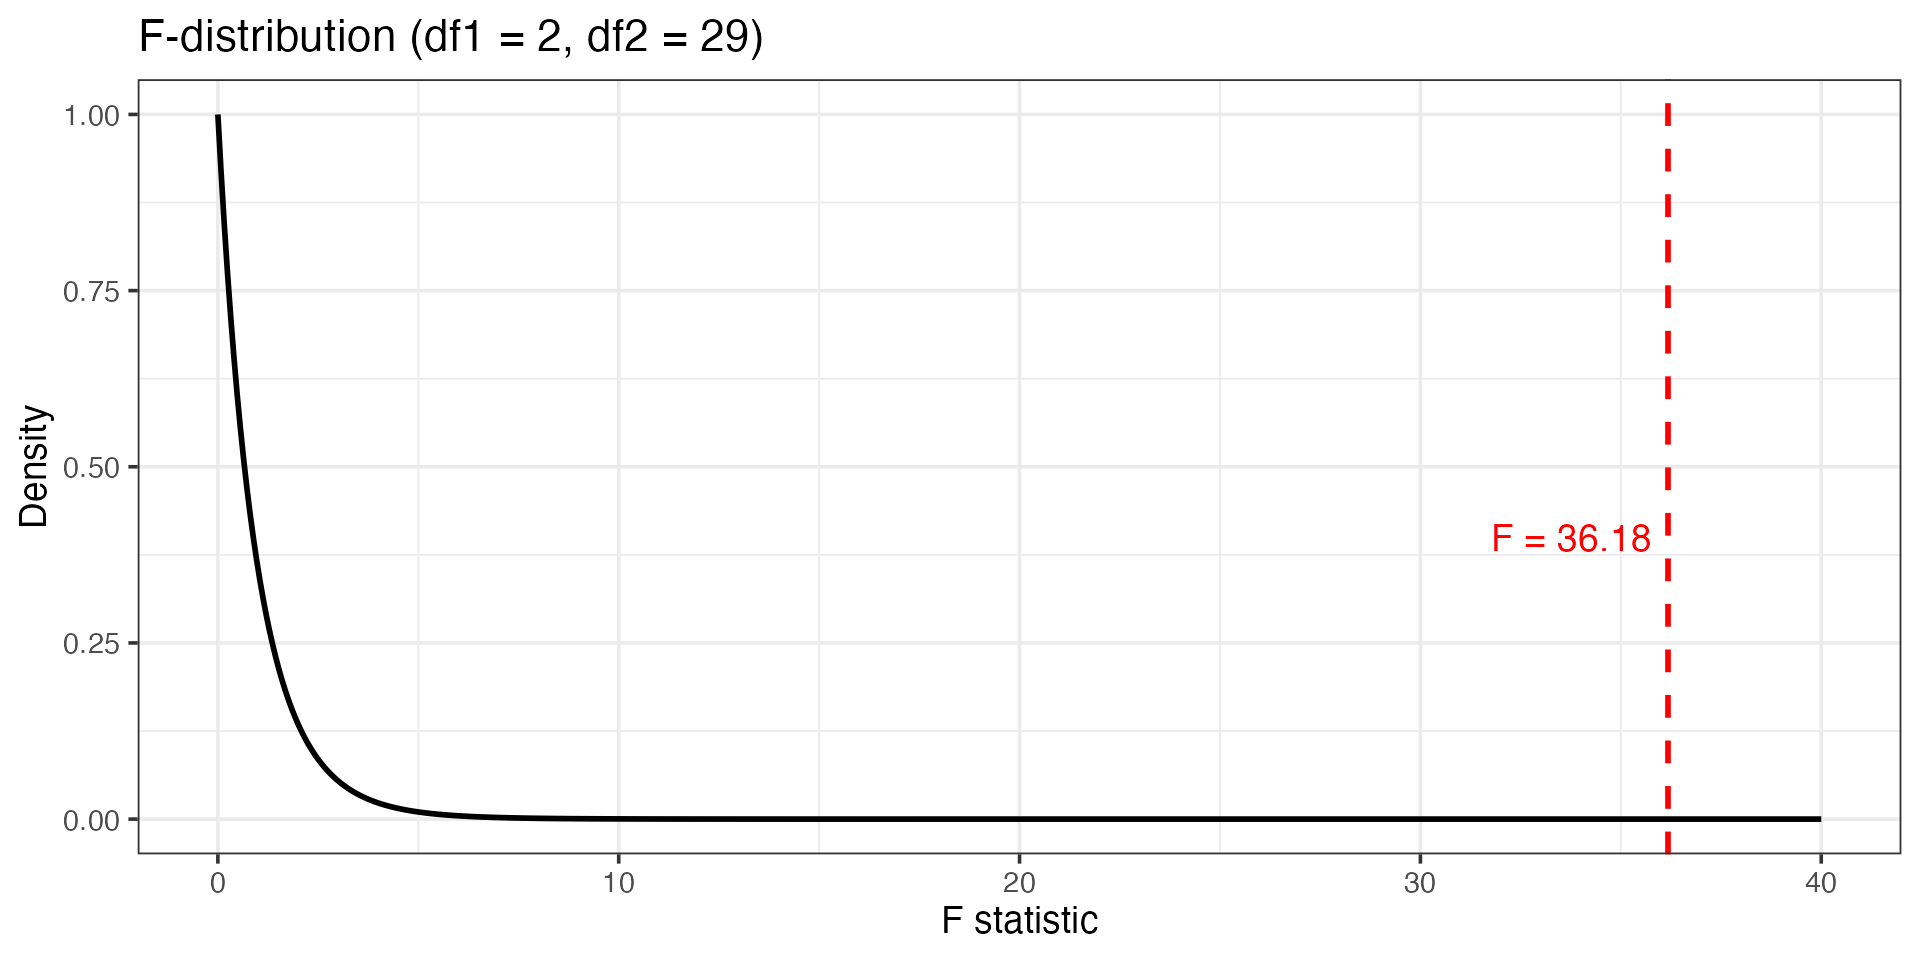

In [47]:
# cell-12
# Plot the F-distribution and shade the p-value area
f_grid <- tibble(f = seq(0, max(F + 2, 40), length.out = 500),
                 density = df(f, df1, df2))

ggplot(f_grid, aes(f, density)) +
  geom_line(linewidth = 1) +
  stat_function(fun = df, args = list(df1 = df1, df2 = df2),
                xlim = c(F, max(F + 2, 40)),
                geom = "area", fill = "red", alpha = 0.5) +
  geom_vline(xintercept = F, color = "red", linetype = "dashed", linewidth = 1) +
  annotate("text", x = F, y = max(f_grid$density) * 0.4, 
           label = paste("F =", round(F, 2)), color = "red", hjust = 1.1, size = 5) +
  labs(title = paste0("F-distribution (df1 = ", df1, ", df2 = ", df2, ")"),
       x = "F statistic",
       y = "Density") +
  theme_bw(base_size = 14)

**<font color= "red">It is time for CLICKER QUESTION!!</font>**

### 1.7 ANOVA in R

To do ANOVA in R, we use the `aov` function: 

```
aov(formula = response ~ grouping_variable,
    data = dataframe)
```

In [48]:
# cell-13
# Solve the problem above using aov
aov(hp ~ cyl, data = cars)

Call:
   aov(formula = hp ~ cyl, data = cars)

Terms:
                      cyl Residuals
Sum of Squares  104030.54  41696.33
Deg. of Freedom         2        29

Residual standard error: 37.91839
Estimated effects may be unbalanced

The `broom::tidy` extracts all the info in a dataframe for you:

In [49]:
# cell-14
# Call broom::tidy on the aov object
broom::tidy(aov(hp ~ cyl, data = cars))

# A tibble: 2 × 6
  term         df   sumsq meansq statistic       p.value
  <chr>     <dbl>   <dbl>  <dbl>     <dbl>         <dbl>
1 cyl           2 104031. 52015.      36.2  0.0000000132
2 Residuals    29  41696.  1438.      NA   NA           

Let's see if it matches what we did. 

- `sumsq` is our SS terms
    -  `sumsq` of `cyl` is SST
    -  `sumsq` of residuals is SSE

In [50]:
# cell-15
SST
SSE

[1] 41696.33

- `meansq` is our MS terms
    -  `meansq` of `cyl` is MST
    -  `meansq` of residuals is MSE

In [51]:
# cell-16
MST
MSE

[1] 1437.805

### 1.8 Assumptions for ANOVA

- The population of all groups follow a Normal distribution;
- All the population have the same variance.
    - In practice, we are fine as long as the largest variance is not multiple times larger than the smallest variance. 
<br>
- The samples are independent across and within each group.

### 1.9 Tukey Honest Significant Difference

The issue with ANOVA is that it only tells us that at least one group has a different mean. But it doesn't tell us which groups are different. 

Once we detect that there is a difference with ANOVA, we can study pairwise difference of means by using Tukey's HSD. Tukey's HSD will basically make pairwise tests, but it will control the probability of Type I Error.

In [52]:
# cell-17
# TukeyHSD
TukeyHSD(aov(hp ~ cyl, data = cars))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = hp ~ cyl, data = cars)

$cyl
         diff       lwr       upr     p adj
6-4  39.64935 -5.627454  84.92616 0.0949068
8-4 126.57792 88.847251 164.30859 0.0000000
8-6  86.92857 43.579331 130.27781 0.0000839


### 1.10 Multiple Comparisons and p-value Correction

When we perform multiple pairwise hypothesis tests simultaneously (for example, comparing all pairs across several groups), the probability of making at least one Type I error (false positive) inflates rapidly.

For $k$ independent tests conducted at significance level $\alpha$:
$$\text{Familywise Error Rate (FWER)} = \text{Pr}(\text{at least one Type I error}) = 1 - (1 - \alpha)^k$$

For instance, with $k = 3$ tests at $\alpha = 0.05$, $\text{FWER} = 1 - (0.95)^3 \approx 0.143$ ($14.3\%$).

To control false positive rates when conducting multiple comparisons, we adjust our significance thresholds or $p$-values:

1. **Bonferroni Correction**:
   - *Goal*: Strictly control the Familywise Error Rate ($\text{FWER} \le \alpha$).
   - *Adjustment*: Divide the significance level by the number of tests ($\alpha_{\text{adjusted}} = \alpha / k$) or equivalently multiply each $p$-value by $k$:
     $$p_{\text{adjusted}} = \min(k \times p, 1)$$
   - *Trade-off*: Highly conservative, which increases the risk of Type II errors (lower statistical power).


2. **False Discovery Rate (FDR) / Benjamini-Hochberg (BH)** (very common in genetics -- massive number hypothesis tests):
   - *Goal*: Control the expected proportion of false positives among all rejected hypotheses (discoveries).
   - *Adjustment*: Ranks $p$-values $p_{(1)} \le p_{(2)} \le \dots \le p_{(k)}$ and finds the largest index $i$ such that:
     $$p_{(i)} \le \frac{i}{k}\alpha$$
     Then, all hypotheses $H_{(1)}, \dots, H_{(i)}$ with rank $\le i$ are rejected.
   - *Trade-off*: Less conservative than Bonferroni, offering higher statistical power to detect true differences.

In R, we can perform pairwise $t$-tests with $p$-value adjustments using `pairwise.t.test()`:

In [53]:
# cell-18
# Pairwise t-tests with Bonferroni correction
pairwise.t.test(cars$hp, cars$cyl, p.adjust.method = "bonferroni")


	Pairwise comparisons using t tests with pooled SD 

data:  cars$hp and cars$cyl 

  4       6      
6 0.12    -      
8 1.2e-08 8.7e-05

P value adjustment method: bonferroni 

In [54]:
# cell-19
# Pairwise t-tests with Benjamini-Hochberg (FDR) correction
pairwise.t.test(cars$hp, cars$cyl, p.adjust.method = "BH")


	Pairwise comparisons using t tests with pooled SD 

data:  cars$hp and cars$cyl 

  4       6      
6 0.039   -      
8 1.2e-08 4.3e-05

P value adjustment method: BH 

Given a vector of raw $p$-values, we can use `p.adjust()` to adjust the p-values:

In [55]:
# cell-20
# Using p.adjust directly on raw p-values
raw_p_values <- c(0.002, 0.015, 0.048, 0.120)

# Bonferroni adjusted p-values
p.adjust(raw_p_values, method = "bonferroni")

# Benjamini-Hochberg (FDR) adjusted p-values
p.adjust(raw_p_values, method = "BH")

[1] 0.008 0.030 0.064 0.120